In [1]:
]activate ../../../

  Activating project at `~/UCLOneDrive/SpatialStructureInMicrobialCommunities/SSMCCode`


In [2]:
using Revise
includet("../../../scripts/single_influx.jl")

In [37]:
using CairoMakie
using GLMakie
CairoMakie.activate!()

In [246]:
N = 20
M = N
B = 3
rsg = get_si_sampler_for_paper(15, 1.; N, M, B);

In [265]:
ps = rsg().mmicrm_params;
N, M = get_Ns(ps)

num_repeats = 20

tol = 1e-9

sols = Vector{Any}(undef, num_repeats)
fss = Vector{Any}(undef, num_repeats)

@tasks for i in 1:num_repeats
    u0 = zeros(N+M)
    for i in 1:N
        u0[i] = 1000 * rand()
    end
    p = make_mmicrm_problem(ps, u0, 1e8);
    s = solve(p, QNDF();
        abstol=tol,
        reltol=tol,
    );
    sols[i] = s
    fss[i] = s.u[end]
end

maximum(map(mmicrmmaxresid, sols))

┌ Warning: At t=426.59347724661353, dt was forced below floating point epsilon 5.684341886080802e-14, and step error estimate = 1.0558852804002006. Aborting. There is either an error in your model specification or the true solution is unstable (or the true solution can not be represented in the precision of Float64).
└ @ SciMLBase ~/.julia/packages/SciMLBase/RPW6n/src/integrator_interface.jl:673


7.830462344602057e22

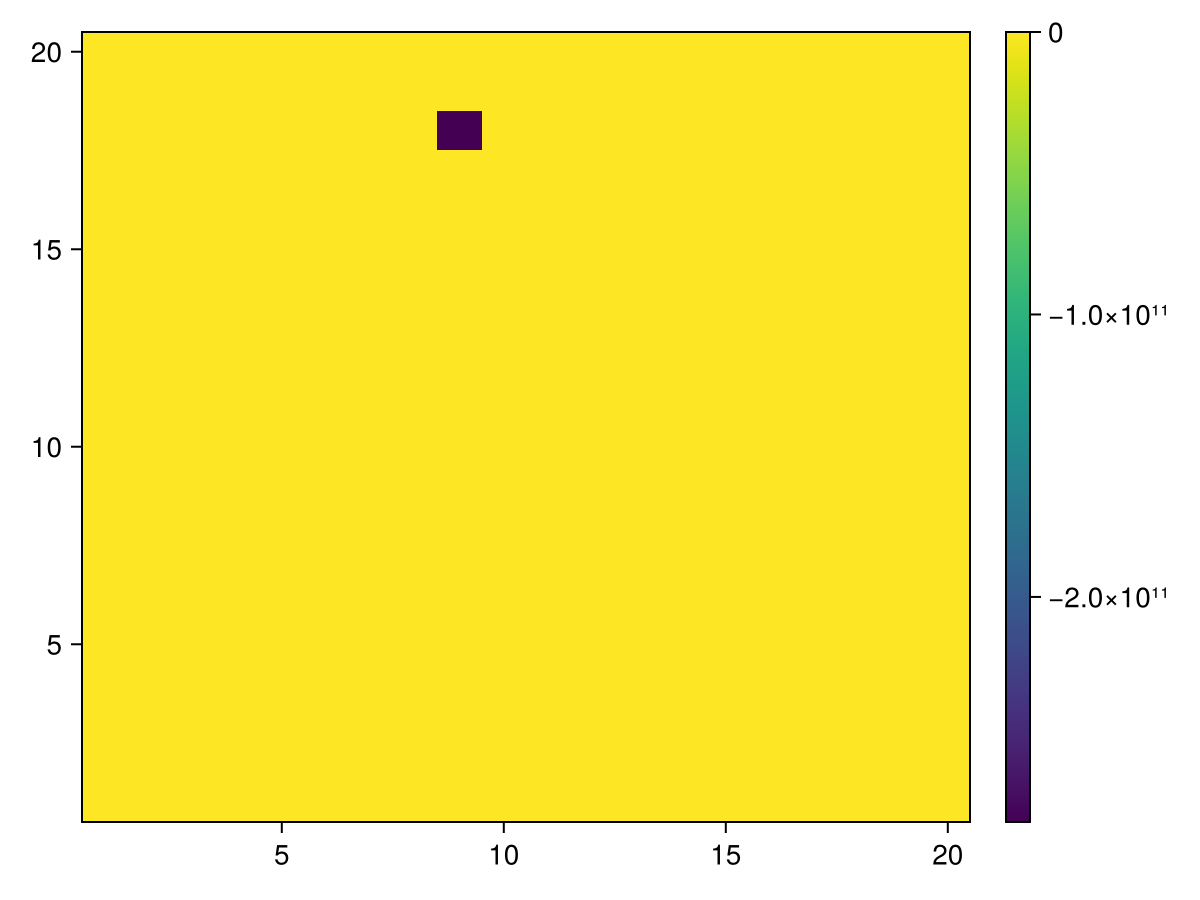

In [266]:
fap = heatmap(hcat([x[1:N] for x in fss]...))
# fap = heatmap(hcat(fss...))
Colorbar(fap.figure[1,2], fap.plot)
fap

In [277]:
s = sols[end-2];

In [281]:
f = plot_mmicrm_sol(s).figure
display(GLMakie.Screen(), f)

GLMakie.Screen(...)